In [ ]:
!pip install pandas matplotlib seaborn plotly
import pandas as pd
df = pd.read_csv('myExpenses1.csv')
df

,Date,Item,Amount,Category,Time,day
0,1/3/2023,chai,7,alone,7:00,Wednesday
1,1/3/2023,chai,20,friend,10:00,Wednesday
2,1/3/2023,juice,15,friend,13:00,Wednesday
3,1/3/2023,rikshow,12,alone,14:00,Wednesday
4,1/3/2023,coffee,12,alone,15:00,Wednesday
...,...,...,...,...,...,...
140,30/3/2023,chai with snaks,15,alone,17:30,Thursday
141,30/3/2023,others,20,alone,19:00,Thursday
142,31/3/2023,chai with snaks,15,alone,9:00,Friday
143,31/3/2023,coldrink,20,friend,15:00,Friday


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns #使得數據視覺化更加簡單和美觀。

In [ ]:
df.describe()

,Amount
count,145.000000
mean,31.786207
std,56.389541
min,5.000000
25%,12.000000
50%,17.000000
75%,30.000000
max,500.000000


In [ ]:
df.isna().sum()

,0
Date,0
Item,0
Amount,0
Category,1
Time,0
day,0


In [ ]:
df.dropna() #删除 DataFrame 中的缺失值（NaN）

,Date,Item,Amount,Category,Time,day
0,1/3/2023,chai,7,alone,7:00,Wednesday
1,1/3/2023,chai,20,friend,10:00,Wednesday
2,1/3/2023,juice,15,friend,13:00,Wednesday
3,1/3/2023,rikshow,12,alone,14:00,Wednesday
4,1/3/2023,coffee,12,alone,15:00,Wednesday
...,...,...,...,...,...,...
140,30/3/2023,chai with snaks,15,alone,17:30,Thursday
141,30/3/2023,others,20,alone,19:00,Thursday
142,31/3/2023,chai with snaks,15,alone,9:00,Friday
143,31/3/2023,coldrink,20,friend,15:00,Friday


In [ ]:
# total amount spended
df.Amount.sum()

4609

In [ ]:
# 將 'Date' 列轉換為日期格式
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# 篩選出2023年3月1日的數據
total_spent = df[df['Date'] == '2023-03-03']['Amount'].sum()
total_spent

117

In [ ]:
df.Item.unique()

array(['chai', 'juice', 'rikshow', 'coffee', 'chai with snaks',
       'coldrink', 'others', 'chiness bhel', 'idli', 'choclate',
       'ice cream', 'shoe', 'faluda', 'chass', 'pizza', 'biryani', 'wifi',
       'chicken', 'recharge', 'petrol', 'samosa', 'freanky', 'maggi'],
      dtype=object)

In [ ]:
# df1 = df.groupby("Item").sum().sort_values(by="Amount",ascending=False).head(10)
df1 = df.groupby("Item")['Amount'].sum().sort_values(ascending=False).head(10)
df1 = df1.reset_index()
df1

,Item,Amount
0,chai with snaks,1080
1,biryani,580
2,shoe,500
3,wifi,350
4,others,335
5,juice,210
6,recharge,210
7,chai,200
8,chicken,180
9,coldrink,165


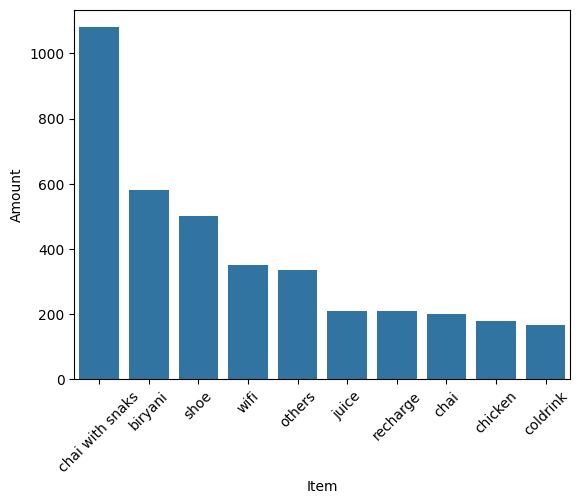

In [ ]:
# top 10 items based on spending
sns.barplot(x=df1.Item, y=df1.Amount,data=df1)

# 旋轉X軸標簽
plt.xticks(rotation=45)

# 保存圖形為 PNG 文件
plt.savefig('shopping_amount.png', dpi=300, bbox_inches='tight')
# dpi=300 提高清晰度
# bbox_inches='tight'：這個參數用於確保圖像的邊界框緊湊，防止標簽被截斷。

# 顯示圖形
plt.show() #在ipynb中可以省略


In [ ]:
#每天花了多少錢？
df.groupby("Date").sum()

,Item,Amount,Category,Time,day
Date,,,,,
2023-03-01,chaichaijuicerikshowcoffeechai with snakscoldr...,111,alonefriendfriendalonealonealonealonealone,7:0010:0013:0014:0015:0017:0021:3012:00,WednesdayWednesdayWednesdayWednesdayWednesdayW...
2023-03-02,chaijuicerikshowcoffeechai with snakschiness bhel,131,alonefriendfriendalonealonefriend,7:0013:0014:0015:0018:0020:00,ThursdayThursdayThursdayThursdayThursdayThursday
2023-03-03,chaichaiidliotherschai with snakschoclate,117,alonefriendfriendalonealonefriend,7:0010:0010:3212:0018:0022:30,FridayFridayFridayFridayFridayFriday
2023-03-04,chaichaijuicerikshowcoffeeotherschaiice cream,126,alonefriendalonealonealonealonealonefriend,7:0010:0012:0012:3015:3012:0017:3021:30,SaturdaySaturdaySaturdaySaturdaySaturdaySaturd...
2023-03-05,chai with snaksotherscoldrinkchaishoefaluda,632,alonealonealonealonealonefriend,9:3010:0015:0018:0017:3022:40,SundaySundaySundaySundaySundaySunday
2023-03-06,chaijuicecoffeechasschai with snaks,71,alonefriendalonefriendalone,7:0012:0015:0015:3017:20,MondayMondayMondayMondayMonday
2023-03-07,chai with snaksidlichaiice creamotherspizzacol...,432,alonefriendfriendfriendalonefriendalonefriend,9:0010:0017:0019:0012:0021:001.08333333323:30,TuesdayTuesdayTuesdayTuesdayTuesdayTuesdayTues...
2023-03-08,chaijuicewificoffeechai with snaks,422,friendfriendalonealonealone,7:0010:0010:3014:0018:00,WednesdayWednesdayWednesdayWednesdayWednesday
2023-03-09,chai with snakschai with snaksothers,60,alonealonealone,9:0017:3019:30,ThursdayThursdayThursday


In [ ]:
# 錢花最多的5天
df2 = df.groupby("Date").sum().sort_values(by="Amount",ascending=False).head(5)
df2 = df2.reset_index()
df2

,Date,Item,Amount,Category,Time,day
0,2023-03-05,chai with snaksotherscoldrinkchaishoefaluda,632,alonealonealonealonealonefriend,9:3010:0015:0018:0017:3022:40,SundaySundaySundaySundaySundaySunday
1,2023-03-07,chai with snaksidlichaiice creamotherspizzacol...,432,alonefriendfriendfriendalonefriendalonefriend,9:0010:0017:0019:0012:0021:001.08333333323:30,TuesdayTuesdayTuesdayTuesdayTuesdayTuesdayTues...
2,2023-03-08,chaijuicewificoffeechai with snaks,422,friendfriendalonealonealone,7:0010:0010:3014:0018:00,WednesdayWednesdayWednesdayWednesdayWednesday
3,2023-03-12,chai with snaksbiryanicoldrinkchairechargecold...,390,alonefriendfriendfriendalonefriend,9:0014:0014:1018:0012:0021:0018:30,SundaySundaySundaySundaySundaySundaySunday
4,2023-03-27,chai with snakschaijuicerikshowbiryanicoldrink...,327,alonefriendfriendalonefriendfriendalone,9:0011:0015:0013:0016:0016:0018:00,MondayMondayMondayMondayMondayMondayMonday



1. **`df.groupby("Date")`**：
   - 這一部分代碼按 `Date` 列對數據框 `df` 進行分組。每個日期的數據會被聚合在一起。

2. **`.sum()`**：
   - 在分組的基礎上，使用 `sum()` 方法對每個分組的數值列（在這裏是 `Amount` 列）進行求和。這將生成一個新的數據框，其中每個日期只保留一行，並且 `Amount` 列的值是該日期下所有相關記錄的總和。

3. **`.sort_values(by="Amount", ascending=False)`**：
   - 這一行代碼根據 `Amount` 列的值進行降序排序（`ascending=False`），使得金額最大的日期排在最前面。

4. **`.head(5)`**：
   - 該方法提取排序後前五行的記錄。這意味著你將得到金額最大的五個日期及其對應的總金額。

5. **`df2 = df2.reset_index()`**：
   - 由於 `groupby()` 操作會使得 `Date` 欄變成索引，這一行程式通過 `reset_index()` 將索引重置為預設的整數索引，並將原來的 `Date` 欄變為普通欄 (Regular Column)。這樣，`df2` 將變成一個新的數據框，包含 `Date` 列和對應的總金額。


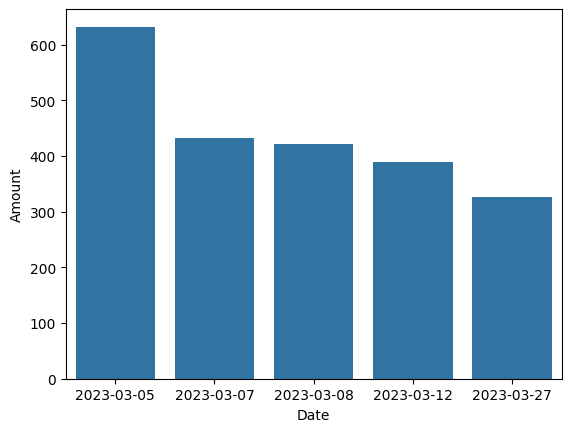

In [ ]:
# on which dates spends more
sns.barplot(x=df2.Date, y=df2.Amount, data=df2)
plt.savefig('most_spends_5days.png', dpi=300, bbox_inches='tight')

In [ ]:
#df3 = df.groupby("day").sum().sort_values(by="Amount",ascending=False)
df3 = df.groupby("day")["Amount"].sum().sort_values(ascending=False)
df3 = df3.reset_index()

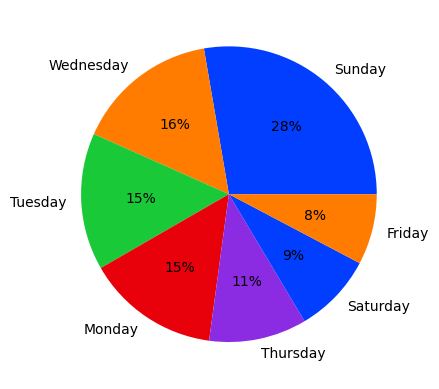

In [ ]:
# which day spends more
colors = sns.color_palette('bright')[0:5]
plt.pie(data=df3,labels=df3.day,colors=colors,x="Amount",autopct='%.0f%%')
plt.savefig('most_spends_days.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df.groupby('Category')['Amount'].sum()

,Amount
Category,
alone,2710
friend,1889


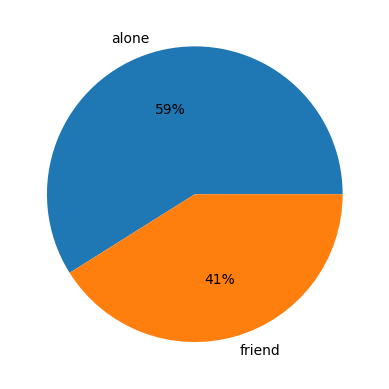

In [ ]:
#spending by categry
plt.pie(labels=df.groupby('Category')['Amount'].sum().index,
       x=df.groupby('Category')['Amount'].sum().values,autopct='%.0f%%')

plt.savefig('spends_category.png', dpi=300, bbox_inches='tight')
plt.show()


1. **`labels=df.groupby('Category')['Amount'].sum().index`**
   - 這一行使用 `groupby` 方法根據 `Category` 列來分組，然後計算每個類別的 `Amount` 總和。接著，使用 `.index` 來取得所有類別的名稱，作為圓餅圖的標籤。

2. **`x=df.groupby('Category')['Amount'].sum().values`**
   - 這一行也是使用 `groupby` 方法，計算每個類別的 `Amount` 總和，但這次用 `.values` 取得這些總和的數值，這些數值將用於圓餅圖的大小。

3. **`autopct='%.0f%%'`**
   - 這一參數用來設定顯示在圓餅圖上的百分比格式。`'%.0f%%'` 代表顯示整數百分比（不帶小數點），後面的 `%%` 是為了顯示百分比符號 `%`。


In [ ]:
# 把奇怪的資料刪掉
# 先將 'Time' 列的數據類型轉換為時間格式，無法轉換的值會被設為 NaT
df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.time
# 刪除 'Time' 列中為 NaT 的行
df[df['Time'].notna()]
df


<ipython-input-18-89f9e2ebd1f6>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.time


,Date,Item,Amount,Category,Time,day
0,2023-03-01,chai,7,alone,07:00:00,Wednesday
1,2023-03-01,chai,20,friend,10:00:00,Wednesday
2,2023-03-01,juice,15,friend,13:00:00,Wednesday
3,2023-03-01,rikshow,12,alone,14:00:00,Wednesday
4,2023-03-01,coffee,12,alone,15:00:00,Wednesday
...,...,...,...,...,...,...
140,2023-03-30,chai with snaks,15,alone,17:30:00,Thursday
141,2023-03-30,others,20,alone,19:00:00,Thursday
142,2023-03-31,chai with snaks,15,alone,09:00:00,Friday
143,2023-03-31,coldrink,20,friend,15:00:00,Friday


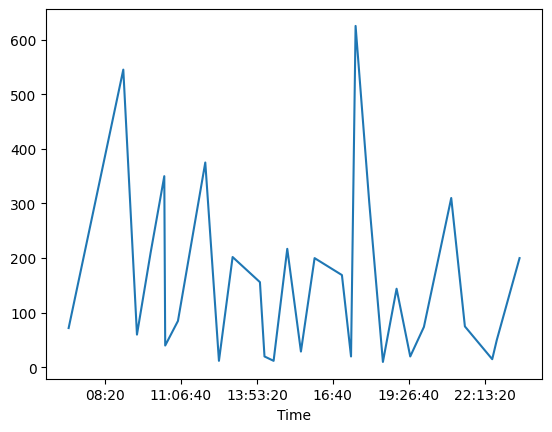

In [ ]:
# 什麼時間花得比較多？
df.groupby("Time")['Amount'].sum().plot()
plt.savefig('spends_time.png', dpi=300, bbox_inches='tight')

In [ ]:

# 每日消費可視化
import plotly.express as px
fig = px.line(x=df.groupby('Date')['Amount'].sum().sort_index().index,
        y=df.groupby('Date')['Amount'].sum().values)

# 顯示圖表
fig.show()

1. **`import plotly.express as px`**
   - 這行是將 Plotly 的 Express 模組匯入，通常用來快速繪製各種圖表，因為它提供了簡單易用的介面。

2. **`px.line(...)`**
   - 這個函數用來繪製折線圖。折線圖可以幫助我們視覺化隨時間變化的數據趨勢。

3. **`x=df.groupby('Date')['Amount'].sum().sort_index().index`**
   - 這部分代碼使用 `groupby` 方法根據 `Date` 列進行分組，然後計算每個日期的 `Amount` 總和。接著使用 `.sort_index()` 將日期按順序排列，最後用 `.index` 取得這些日期作為 x 軸的數值。

4. **`y=df.groupby('Date')['Amount'].sum().values`**
   - 這部分也是使用 `groupby` 方法計算每個日期的 `Amount` 總和，然後用 `.values` 取得這些總和的數值，這些數值將用作 y 軸的數據。
